In [1]:
import zarr
import s3fs
import xarray as xr
from pathlib import Path

Read from S3 bucket directly

In [ ]:
eodc_s3 = s3fs.S3FileSystem(
    key="",
    secret="",
    client_kwargs={
        "endpoint_url": "https://objects.eodc.eu"
    })
zarr_stores = eodc_s3.ls("destine-climate-dt/Austria")
zarr_stores

Read from disc

In [5]:
root_path = s3fs.S3Map(root="destine-climate-dt/Austria", s3=eodc_s3)
zrec = []
for zs in eodc_s3.ls("destine-climate-dt/Austria"):
    if zs.endswith(".zarr"):
        zrec.append({"file": zs, "datetime": xr.open_zarr(s3fs.S3Map(root=zs, s3=eodc_s3))["datetime"].min().values.item()})
print(f"{len(zrec)} zarr stores found.")

8 zarr stores found.


In [6]:
from datetime import datetime
records_sorted = sorted(
    zrec,
    key=lambda r: r["datetime"])
records_sorted
zstores_sorted = [zfd["file"] for zfd in records_sorted]

In [10]:
zstores_sorted

['destine-climate-dt/Austria/IFS-NEMO_sfc_CMIP6_hist.zarr',
 'destine-climate-dt/Austria/IFS-NEMO_sfc_HighResMIP_cont.zarr',
 'destine-climate-dt/Austria/ICON_sfc_CMIP6_hist.zarr',
 'destine-climate-dt/Austria/IFS-FESOM_sfc_story-nudging_Tplus2.0K.zarr',
 'destine-climate-dt/Austria/IFS-FESOM_sfc_story-nudging_cont.zarr',
 'destine-climate-dt/Austria/IFS-FESOM_sfc_story-nudging_hist.zarr',
 'destine-climate-dt/Austria/ICON_sfc_ScenarioMIP_SSP3-7.0.zarr',
 'destine-climate-dt/Austria/IFS-NEMO_sfc_ScenarioMIP_SSP3-7.0.zarr']

In [16]:
test = xr.open_zarr(s3fs.S3Map(root=zstores_sorted[0], s3=eodc_s3))
test

<xarray.Dataset> Size: 3GB
Dimensions:    (pointid: 2067, levelist: 1, number: 1, datetime: 1, t: 105192)
Coordinates:
  * pointid    (pointid) int64 17kB 7 15 16 10 23 ... 2062 2063 2064 2065 2066
    latitude   (pointid) float64 17kB dask.array<chunksize=(1,), meta=np.ndarray>
    longitude  (pointid) float64 17kB dask.array<chunksize=(1,), meta=np.ndarray>
  * levelist   (levelist) int64 8B 0
  * number     (number) int64 8B 0
  * datetime   (datetime) <U20 80B '2001-12-31 00:00:00Z'
  * t          (t) datetime64[ns] 842kB 1990-01-01 ... 2001-12-31T23:00:00
Data variables:
    2t         (pointid, levelist, number, datetime, t) float64 2GB dask.array<chunksize=(1, 1, 1, 1, 105192), meta=np.ndarray>
    tp         (pointid, levelist, number, datetime, t) float64 2GB dask.array<chunksize=(1, 1, 1, 1, 105192), meta=np.ndarray>
Attributes: (12/14)
    activity:       cmip6
    class:          d1
    dataset:        climate-dt
    experiment:     hist
    expver:         0001
    generation:     1
    ...             ...
    realization:    1
    resolution:     high
    stream:         clte
    type:           fc
    number:         0
    Forecast date:  2001-12-31 00:00:00Z

get the first and last datetimes from the sorted zarr stores

In [17]:
print(test)

<xarray.Dataset> Size: 3GB
Dimensions:    (pointid: 2067, levelist: 1, number: 1, datetime: 1, t: 105192)
Coordinates:
  * pointid    (pointid) int64 17kB 7 15 16 10 23 ... 2062 2063 2064 2065 2066
    latitude   (pointid) float64 17kB dask.array<chunksize=(1,), meta=np.ndarray>
    longitude  (pointid) float64 17kB dask.array<chunksize=(1,), meta=np.ndarray>
  * levelist   (levelist) int64 8B 0
  * number     (number) int64 8B 0
  * datetime   (datetime) <U20 80B '2001-12-31 00:00:00Z'
  * t          (t) datetime64[ns] 842kB 1990-01-01 ... 2001-12-31T23:00:00
Data variables:
    2t         (pointid, levelist, number, datetime, t) float64 2GB dask.array<chunksize=(1, 1, 1, 1, 105192), meta=np.ndarray>
    tp         (pointid, levelist, number, datetime, t) float64 2GB dask.array<chunksize=(1, 1, 1, 1, 105192), meta=np.ndarray>
Attributes: (12/14)
    activity:       cmip6
    class:          d1
    dataset:        climate-dt
    experiment:     hist
    expver:         0001
    generat

In [11]:
min_date = xr.open_zarr(s3fs.S3Map(root=zstores_sorted[0], s3=eodc_s3)).coords["t"].values.astype("datetime64[s]").min()
max_date = xr.open_zarr(s3fs.S3Map(root=zstores_sorted[-1], s3=eodc_s3)).coords["t"].values.astype("datetime64[s]").max()

In [12]:
print(min_date)
print(max_date)

1990-01-01T00:00:00
2039-12-31T23:00:00


In [13]:
datetime_samples = xr.date_range(start=min_date, end=max_date, freq="1h")
n_datetime_samples = datetime_samples.size
n_datetime_samples

438288

get number healpix grid points

In [14]:
max_points = max(
    xr.open_zarr(s3fs.S3Map(root=zs, s3=eodc_s3)).sizes["pointid"]
    for zs in zstores_sorted
)

In [15]:
max_points

2079

In [ ]:
# n_grid_points = xr.open_dataset(s3fs.S3Map(root=zstores_sorted[0], s3=eodc_s3)).coords["pointid"].values.size
# # n_grid_points = xr.open_dataset(zstores_sorted[0]).coords["points"].values.size
# n_grid_points

629

In [72]:
dummy_ds = xr.open_dataset(zstores_sorted[1])
healpix_lat = dummy_ds.coords["latitude"].values
healpix_lon = dummy_ds.coords["longitude"].values

In [73]:
import pandas as pd
geosphere_stations = pd.read_csv("./location_hourly_daily_stations_2007_2025.csv")
geosphere_stations

,id,Stationsname,Lon,Lat,Höhe [m],Startdatum,Enddatum,Bundesland
0,1,Aflenz,15.240690,47.545940,783.2,1983-05-01 00:00:00+00:00,2100-12-31 00:00:00+00:00,Steiermark
1,2,Aigen im Ennstal,14.138260,47.532780,641.0,1939-03-01 00:00:00+00:00,2100-12-31 00:00:00+00:00,Steiermark
2,3,Allentsteig,15.366940,48.690830,598.8,1983-10-01 00:00:00+00:00,2100-12-31 00:00:00+00:00,Niederösterreich
3,4,Amstetten,14.895000,48.108890,266.0,1936-01-01 00:00:00+00:00,2100-12-31 00:00:00+00:00,Niederösterreich
4,5,Bad Aussee,13.758440,47.610500,743.1,1983-09-01 00:00:00+00:00,2100-12-31 00:00:00+00:00,Steiermark
...,...,...,...,...,...,...,...,...
624,12500,Bischofshofen,13.216670,47.400000,550.0,1980-06-02 13:00:00+00:00,2008-06-30 23:00:00+00:00,Salzburg
625,14520,Prutz,10.666667,47.066666,870.0,1967-07-01 00:00:00+00:00,2008-01-31 23:00:00+00:00,Tirol
626,15600,Obertauern,13.566670,47.266670,1742.0,1984-08-23 14:00:00+00:00,2008-06-30 23:00:00+00:00,Salzburg
627,19600,St. Lorenzen im Lesachtal,12.783334,46.700001,1260.0,1980-01-01 00:00:00+00:00,2007-12-31 23:00:00+00:00,Kärnten


In [74]:
# Get the stationid order from the zarr store
dummy_ds = xr.open_zarr(zstores_sorted[0])
stationids = dummy_ds.coords["stationid"].values  # the 629 IDs in zarr order

# Reindex geosphere_stations to match zarr stationid order
geosphere_stations_sorted = geosphere_stations.set_index("id").loc[stationids]

# Extract lat/lon in the correct order
healpix_lat = geosphere_stations_sorted["Lat"].values  # shape (629,)
healpix_lon = geosphere_stations_sorted["Lon"].values  # shape (629,)

create an empty zarr store where all the data gets written to

In [75]:
# import dask.array as da
# import numpy as np

# climatedt_zarr = Path("IFS-NEMO-CMIP6-ts.zarr")
# points_chunksize = 100

# data_arr = da.zeros((n_datetime_samples, n_grid_points), chunks=(n_datetime_samples, points_chunksize), dtype=np.float64)
# ds = xr.Dataset(data_vars={"2t": (("datetimes", "points"), data_arr),
#                            "tp": (("datetimes", "points"), data_arr)},
#                 coords={"datetimes": (("datetimes"), datetime_samples),
#                         "points":(("points"), np.arange(n_grid_points)),
#                         "latitude": (("points"), healpix_lat),
#                         "longitude": (("points"), healpix_lon)})
# ds.to_zarr(climatedt_zarr, mode="w", compute=False,
#            encoding={
#                "datetimes": {
#                    "chunks": n_datetime_samples
#                },
#                "points": {
#                    "chunks": n_grid_points
#                },
#                "latitude": {
#                    "chunks": n_grid_points
#                },
#                "longitude": {
#                    "chunks": n_grid_points
#                }
#            })

In [4]:
climatedt_zarr = s3fs.S3Map(root="destine-climate-dt/climate-dt.zarr", s3=eodc_s3)
print(climatedt_zarr)

In [ ]:
import dask.array as da
import numpy as np
import xarray as xr
from pathlib import Path

# climatedt_zarr = Path("climate-dt.zarr")
climatedt_zarr = s3fs.S3Map(root="destine-climate-dt/Austria/climate-dt.zarr", s3=eodc_s3)

points_chunksize = 100

group_names = [
    "IFS-NEMO-CMIP6-hist",
    "IFS-NEMO-HighResMIP-cont",
    "IFS-NEMO-ScenarioMIP-SSP3-7.0",
    "IFS-FESOM-story-nudging-cont",
    "IFS-FESOM-story-nudging-hist",
    "IFS-FESOM-story-nudging-Tplus2.0K",
]

def get_store(group_name):
    return s3fs.S3Map(
        root=f"destine-climate-dt/climate-dt.zarr/{group_name}",
        s3=eodc_s3
    )

for i, group_name in enumerate(group_names):
    data_arr = da.zeros(
        (n_datetime_samples, max_points),
        chunks=(n_datetime_samples, points_chunksize),
        dtype=np.float64
    )

    ds = xr.Dataset(
        data_vars={
            "2t": (("datetimes", "points"), data_arr),
            "tp":  (("datetimes", "points"), data_arr),
        },
        coords={
            "datetimes": (["datetimes"], datetime_samples),
            "points":    (["points"],    np.arange(max_points)),
            "latitude":  (["points"],    healpix_lat),
            "longitude": (["points"],    healpix_lon),
        }
    )

    ds.to_zarr(
        # climatedt_zarr,
        get_store(group_name),
        mode="w" if i == 0 else "a",  # create store on first write, append after
        # group=group_name,
        compute=False,
        encoding={
            "2t":       {"chunks": (n_datetime_samples, points_chunksize)},
            "tp":       {"chunks": (n_datetime_samples, points_chunksize)},
            "datetimes": {"chunks": n_datetime_samples},
            "points":   {"chunks": max_points},
            "latitude": {"chunks": max_points},
            "longitude":{"chunks": max_points},
        }
    )

/home/koenifra/Projects/dt-climate-zarr/dt/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/home/koenifra/Projects/dt-climate-zarr/dt/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/home/koenifra/Projects/dt-climate-zarr/dt/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/home/koenifra/Projects/dt-climate-zarr/dt/lib/python3.11/site-packages/zarr/api/asynchronous.py:247

In [87]:
print(climatedt_zarr)

In [114]:
import zarr
store = zarr.open(str("climate-dt.zarr"), mode="r")
print(store.tree())

/
├── IFS-FESOM-story-nudging-Tplus2.0K
│   ├── 2t (438288, 629) float64
│   ├── datetimes (438288,) int64
│   ├── latitude (629,) float64
│   ├── longitude (629,) float64
│   ├── points (629,) int64
│   └── tp (438288, 629) float64
├── IFS-FESOM-story-nudging-cont
│   ├── 2t (438288, 629) float64
│   ├── datetimes (438288,) int64
│   ├── latitude (629,) float64
│   ├── longitude (629,) float64
│   ├── points (629,) int64
│   └── tp (438288, 629) float64
├── IFS-FESOM-story-nudging-hist
│   ├── 2t (438288, 629) float64
│   ├── datetimes (438288,) int64
│   ├── latitude (629,) float64
│   ├── longitude (629,) float64
│   ├── points (629,) int64
│   └── tp (438288, 629) float64
├── IFS-NEMO-CMIP6-hist
│   ├── 2t (438288, 629) float64
│   ├── datetimes (438288,) int64
│   ├── latitude (629,) float64
│   ├── longitude (629,) float64
│   ├── points (629,) int64
│   └── tp (438288, 629) float64
├── IFS-NEMO-HighResMIP-cont
│   ├── 2t (438288, 629) float64
│   ├── datetimes (438288,) int64
│ 

now we want to fill each chunk with the corresponding data.

In [16]:
chunk_pos_start = np.arange(0, n_grid_points, points_chunksize)
chunk_pos_end = np.append(np.arange(points_chunksize-1, n_grid_points, points_chunksize), [n_grid_points-1])

In [111]:
dtcube = zarr.open(climatedt_zarr, mode="a")
# group = dtcube["IFS-NEMO-CMIP6-hist"]
# group = dtcube["IFS-NEMO-HighResMIP-cont"]
group = dtcube["IFS-NEMO-ScenarioMIP-SSP3-7.0"]
# group = dtcube["IFS-FESOM-story-nudging-cont"]
# group = dtcube["IFS-FESOM-story-nudging-hist"]
# group = dtcube["IFS-FESOM-story-nudging-Tplus2.0K"]
zarr_2t = group["2t"]
zarr_tp = group["tp"]


In [108]:
zstores_sorted

[PosixPath('../dt_climate-zarr-save/IFS-NEMO_sfc_CMIP6_hist.zarr'),
 PosixPath('../dt_climate-zarr-save/IFS-NEMO_sfc_HighResMIP_cont.zarr'),
 PosixPath('../dt_climate-zarr-save/IFS-FESOM_sfc_story-nudging_cont.zarr'),
 PosixPath('../dt_climate-zarr-save/IFS-FESOM_sfc_story-nudging_hist.zarr'),
 PosixPath('../dt_climate-zarr-save/IFS-FESOM_sfc_story-nudging_Tplus2.0K.zarr'),
 PosixPath('../dt_climate-zarr-save/IFS-NEMO_sfc_ScenarioMIP_SSP3-7.zarr')]

In [112]:
zstore = zstores_sorted[5]
zstore

PosixPath('../dt_climate-zarr-save/IFS-NEMO_sfc_ScenarioMIP_SSP3-7.zarr')

In [113]:
  # change index to control which one you're writing
ds = xr.open_zarr(zstore)

# squeeze out all size-1 dims -> shape (stationid, t)
ds_squeezed = ds.squeeze(["latitude", "longitude", "levelist", "number", "datetime"])

# reorder stationid to match points order
ds_squeezed = ds_squeezed.sel(stationid=stationids)

# get time slice indices
t_min = ds_squeezed.coords["t"].values.min().astype("datetime64[s]")
t_max = ds_squeezed.coords["t"].values.max().astype("datetime64[s]")

t_start = np.searchsorted(datetime_samples, t_min)
t_end = np.searchsorted(datetime_samples, t_max) + 1

print(f"Store: {zstore.name}")
print(f"Time range: {t_min} -> {t_max}")
print(f"Time slice indices: {t_start}:{t_end}")
print(f"Data shape after squeeze+transpose: {ds_squeezed['2t'].transpose('t', 'stationid').shape}")

# transpose to (t, stationid) = (datetimes, points)
data_2t = ds_squeezed["2t"].transpose("t", "stationid").values
data_tp = ds_squeezed["tp"].transpose("t", "stationid").values

zarr_2t[t_start:t_end, :] = data_2t
zarr_tp[t_start:t_end, :] = data_tp

print(f"Done writing {zstore.name}")

Store: IFS-NEMO_sfc_ScenarioMIP_SSP3-7.zarr
Time range: 2020-01-01T00:00:00 -> 2039-12-31T23:00:00
Time slice indices: 262968:438288
Data shape after squeeze+transpose: (175320, 629)
Done writing IFS-NEMO_sfc_ScenarioMIP_SSP3-7.zarr


Verify that data was written correctly.

/tmp/ipykernel_17861/865114452.py:2: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  zstore_timedim = xr.open_zarr(climatedt_zarr, group="IFS-NEMO-HighResMIP-cont", chunks="auto",)
/tmp/ipykernel_17861/865114452.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "datetimes" starting at index 275035. This could degrade performance. Instead, consider rechunking after loading.
  zstore_timedim = xr.open_zarr(climatedt_zarr, group="IFS-NEMO-HighResMIP-cont", chunks="auto",)
/tmp/ipykernel_

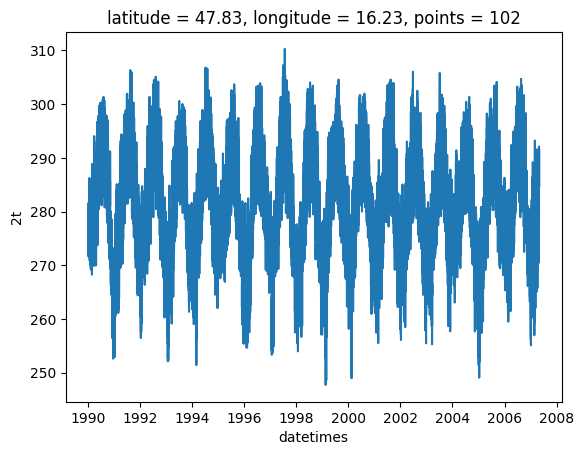

In [ ]:
# zstore_timedim = xr.open_zarr(climatedt_zarr, group="IFS-NEMO-CMIP6-hist", chunks="auto")
zstore_timedim = xr.open_zarr(climatedt_zarr, group="IFS-NEMO-HighResMIP-cont", chunks="auto",)
# zstore_timedim = xr.open_zarr(climatedt_zarr, group="IFS-NEMO-ScenarioMIP-SSP3-7.0", chunks="auto")
# zstore_timedim = xr.open_zarr(climatedt_zarr, group="IFS-FESOM-story-nudging-cont", chunks="auto")
# zstore_timedim = xr.open_zarr(climatedt_zarr, group="IFS-FESOM-story-nudging-hist", chunks="auto")
# zstore_timedim = xr.open_zarr(climatedt_zarr, group="IFS-FESOM-story-nudging-Tplus2.0K", chunks="auto")
zstore_timedim["2t"].isel(points=102).plot()

In [ ]:
# zstore_timedim = xr.open_zarr(climatedt_zarr, group="IFS-NEMO-CMIP6-hist", chunks="auto")
zstore_timedim = xr.open_zarr("../", chunks="auto",)
# zstore_timedim = xr.open_zarr(climatedt_zarr, group="IFS-NEMO-ScenarioMIP-SSP3-7.0", chunks="auto")
# zstore_timedim = xr.open_zarr(climatedt_zarr, group="IFS-FESOM-story-nudging-cont", chunks="auto")
# zstore_timedim = xr.open_zarr(climatedt_zarr, group="IFS-FESOM-story-nudging-hist", chunks="auto")
# zstore_timedim = xr.open_zarr(climatedt_zarr, group="IFS-FESOM-story-nudging-Tplus2.0K", chunks="auto")
zstore_timedim["2t"].isel(points=102).plot()

In [16]:
import warnings
warnings.filterwarnings("ignore")

In [17]:
zstore = xr.open_zarr(climatedt_zarr, chunks="auto",)
zstore

<xarray.Dataset> Size: 0B
Dimensions:  ()
Data variables:
    *empty*

In [18]:
zstore_nemo = xr.open_zarr(climatedt_zarr, group="IFS-NEMO-HighResMIP-cont", chunks=100)
zstore_nemo

<xarray.Dataset> Size: 4GB
Dimensions:    (datetimes: 438288, points: 629)
Coordinates:
  * datetimes  (datetimes) datetime64[ns] 4MB 1990-01-01 ... 2039-12-31T23:00:00
  * points     (points) int64 5kB 0 1 2 3 4 5 6 ... 622 623 624 625 626 627 628
    latitude   (points) float64 5kB dask.array<chunksize=(100,), meta=np.ndarray>
    longitude  (points) float64 5kB dask.array<chunksize=(100,), meta=np.ndarray>
Data variables:
    2t         (datetimes, points) float64 2GB dask.array<chunksize=(100, 100), meta=np.ndarray>
    tp         (datetimes, points) float64 2GB dask.array<chunksize=(100, 100), meta=np.ndarray>

In [19]:
dt = xr.open_datatree(climatedt_zarr, engine="zarr", chunks=100)
dt

<xarray.DataTree>
Group: /
├── Group: /IFS-FESOM-story-nudging-cont
│       Dimensions:    (datetimes: 438288, points: 629)
│       Coordinates:
│         * datetimes  (datetimes) datetime64[ns] 4MB 1990-01-01 ... 2039-12-31T23:00:00
│         * points     (points) int64 5kB 0 1 2 3 4 5 6 ... 622 623 624 625 626 627 628
│           latitude   (points) float64 5kB dask.array<chunksize=(100,), meta=np.ndarray>
│           longitude  (points) float64 5kB dask.array<chunksize=(100,), meta=np.ndarray>
│       Data variables:
│           2t         (datetimes, points) float64 2GB dask.array<chunksize=(100, 100), meta=np.ndarray>
│           tp         (datetimes, points) float64 2GB dask.array<chunksize=(100, 100), meta=np.ndarray>
├── Group: /IFS-FESOM-story-nudging-Tplus2.0K
│       Dimensions:    (datetimes: 438288, points: 629)
│       Coordinates:
│         * datetimes  (datetimes) datetime64[ns] 4MB 1990-01-01 ... 2039-12-31T23:00:00
│         * points     (points) int64 5kB 0 1 2 3 4 5 6 ... 622 623 624 625 626 627 628
│           latitude   (points) float64 5kB dask.array<chunksize=(100,), meta=np.ndarray>
│           longitude  (points) float64 5kB dask.array<chunksize=(100,), meta=np.ndarray>
│       Data variables:
│           2t         (datetimes, points) float64 2GB dask.array<chunksize=(100, 100), meta=np.ndarray>
│           tp         (datetimes, points) float64 2GB dask.array<chunksize=(100, 100), meta=np.ndarray>
├── Group: /IFS-NEMO-CMIP6-hist
│       Dimensions:    (datetimes: 438288, points: 629)
│       Coordinates:
│         * datetimes  (datetimes) datetime64[ns] 4MB 1990-01-01 ... 2039-12-31T23:00:00
│         * points     (points) int64 5kB 0 1 2 3 4 5 6 ... 622 623 624 625 626 627 628
│           latitude   (points) float64 5kB dask.array<chunksize=(100,), meta=np.ndarray>
│           longitude  (points) float64 5kB dask.array<chunksize=(100,), meta=np.ndarray>
│       Data variables:
│           2t         (datetimes, points) float64 2GB dask.array<chunksize=(100, 100), meta=np.ndarray>
│           tp         (datetimes, points) float64 2GB dask.array<chunksize=(100, 100), meta=np.ndarray>
├── Group: /IFS-FESOM-story-nudging-hist
│       Dimensions:    (datetimes: 438288, points: 629)
│       Coordinates:
│         * datetimes  (datetimes) datetime64[ns] 4MB 1990-01-01 ... 2039-12-31T23:00:00
│         * points     (points) int64 5kB 0 1 2 3 4 5 6 ... 622 623 624 625 626 627 628
│           latitude   (points) float64 5kB dask.array<chunksize=(100,), meta=np.ndarray>
│           longitude  (points) float64 5kB dask.array<chunksize=(100,), meta=np.ndarray>
│       Data variables:
│           2t         (datetimes, points) float64 2GB dask.array<chunksize=(100, 100), meta=np.ndarray>
│           tp         (datetimes, points) float64 2GB dask.array<chunksize=(100, 100), meta=np.ndarray>
├── Group: /IFS-NEMO-ScenarioMIP-SSP3-7.0
│       Dimensions:    (datetimes: 438288, points: 629)
│       Coordinates:
│         * datetimes  (datetimes) datetime64[ns] 4MB 1990-01-01 ... 2039-12-31T23:00:00
│         * points     (points) int64 5kB 0 1 2 3 4 5 6 ... 622 623 624 625 626 627 628
│           latitude   (points) float64 5kB dask.array<chunksize=(100,), meta=np.ndarray>
│           longitude  (points) float64 5kB dask.array<chunksize=(100,), meta=np.ndarray>
│       Data variables:
│           2t         (datetimes, points) float64 2GB dask.array<chunksize=(100, 100), meta=np.ndarray>
│           tp         (datetimes, points) float64 2GB dask.array<chunksize=(100, 100), meta=np.ndarray>
└── Group: /IFS-NEMO-HighResMIP-cont
        Dimensions:    (datetimes: 438288, points: 629)
        Coordinates:
          * datetimes  (datetimes) datetime64[ns] 4MB 1990-01-01 ... 2039-12-31T23:00:00
          * points     (points) int64 5kB 0 1 2 3 4 5 6 ... 622 623 624 625 626 627 628
            latitude   (points) float64 5kB dask.array<chunksize=(100,), meta=np.ndarray>
            longitude  (points) float64 5kB dask.a